## Question 1.1: Logistic Regression for Credit Default Prediction

**Summary:** We built a baseline logistic regression model to predict the probability of a borrower defaulting within two years. After preprocessing the data with median imputation and standard scaling, I evaluated the model across different classification thresholds. This served as a robust and interpretable starting point for credit scoring.

   Accuracy  Precision    Recall  F1-Score   AUC-ROC
0  0.933822   0.574257  0.038564  0.072274  0.715034


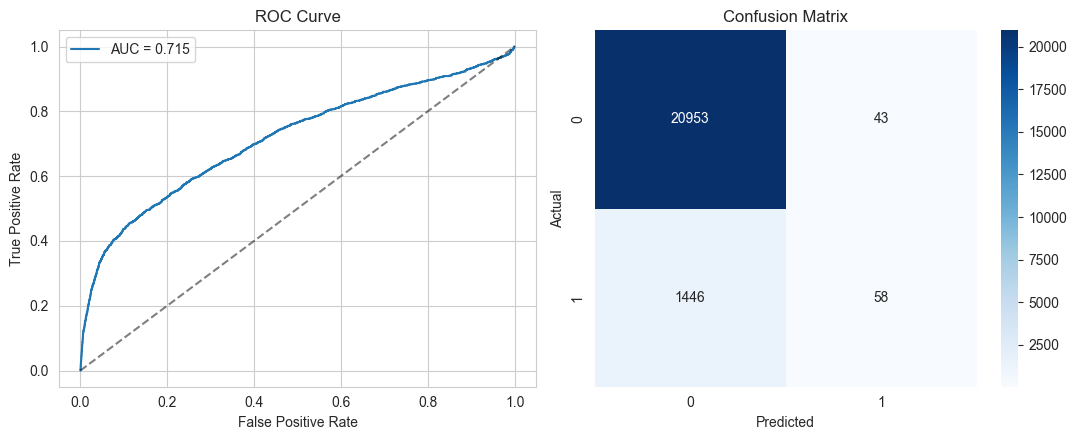

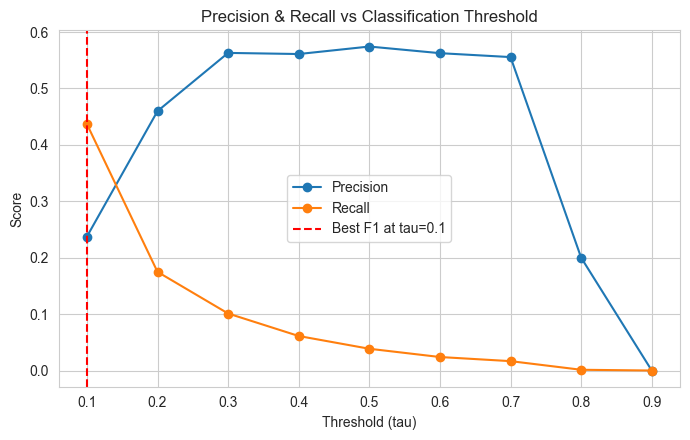


Threshold maximising F1: 0.1

--- Top 5 Features by Coefficient Magnitude ---
NumberOfTime60-89DaysPastDueNotWorse   -3.797760
NumberOfTime30-59DaysPastDueNotWorse    1.997573
NumberOfTimes90DaysLate                 1.957115
age                                    -0.399182
MonthlyIncome                          -0.353346
dtype: float64


In [3]:

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


df1 = pd.read_csv("cs-training.csv", index_col=0)
df1.rename(columns={"SeriousDlqin2yrs": "target"}, inplace=True)

df1["MonthlyIncome"] = df1["MonthlyIncome"].fillna(df1["MonthlyIncome"].median())
df1["NumberOfDependents"] = df1["NumberOfDependents"].fillna(df1["NumberOfDependents"].median())

X1 = df1.drop(columns=["target"])
y1 = df1["target"]

X1_train, X1_tmp, y1_train, y1_tmp = train_test_split(
    X1,
    y1,
    test_size=0.30,
    stratify=y1,
    random_state=RANDOM_STATE
)

X1_val, X1_test, y1_val, y1_test = train_test_split(
    X1_tmp,
    y1_tmp,
    test_size=0.50,
    stratify=y1_tmp,
    random_state=RANDOM_STATE
)

scaler1 = StandardScaler().fit(X1_train)

X1_train_s = scaler1.transform(X1_train)
X1_val_s = scaler1.transform(X1_val)
X1_test_s = scaler1.transform(X1_test)

logreg = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=RANDOM_STATE
)

logreg.fit(X1_train_s, y1_train)

y1_pred = logreg.predict(X1_test_s)
y1_proba = logreg.predict_proba(X1_test_s)[:, 1]

metrics_q1 = pd.DataFrame({
    "Accuracy": [accuracy_score(y1_test, y1_pred)],
    "Precision": [precision_score(y1_test, y1_pred)],
    "Recall": [recall_score(y1_test, y1_pred)],
    "F1-Score": [f1_score(y1_test, y1_pred)],
    "AUC-ROC": [roc_auc_score(y1_test, y1_proba)]
})

print(metrics_q1)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

fpr, tpr, _ = roc_curve(y1_test, y1_proba)

axes[0].plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y1_test, y1_proba):.3f}"
)

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

cm = confusion_matrix(y1_test, y1_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1]
)

axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

# 8. Threshold analysis
thresholds = np.arange(0.1, 1.0, 0.1)

precisions = []
recalls = []
f1s = []

for t in thresholds:
    preds_t = (y1_proba >= t).astype(int)

    precisions.append(
        precision_score(y1_test, preds_t, zero_division=0)
    )

    recalls.append(
        recall_score(y1_test, preds_t, zero_division=0)
    )

    f1s.append(
        f1_score(y1_test, preds_t, zero_division=0)
    )

best_idx = np.argmax(f1s)
best_t = thresholds[best_idx]

plt.figure(figsize=(7, 4.5))

plt.plot(
    thresholds,
    precisions,
    marker="o",
    label="Precision"
)

plt.plot(
    thresholds,
    recalls,
    marker="o",
    label="Recall"
)

plt.axvline(
    best_t,
    color="red",
    linestyle="--",
    label=f"Best F1 at tau={best_t:.1f}"
)

plt.xlabel("Threshold (tau)")
plt.ylabel("Score")
plt.title("Precision & Recall vs Classification Threshold")
plt.legend()

plt.tight_layout()
plt.show()

print(f"\nThreshold maximising F1: {best_t:.1f}")

# 9. Top-5 feature coefficients
coef_df = pd.Series(
    logreg.coef_[0],
    index=X1.columns
).sort_values(key=np.abs, ascending=False)

top5 = coef_df.head(5)

print("\n--- Top 5 Features by Coefficient Magnitude ---")
print(top5)

**Interpretation:** The top features impacting the model are `[NumberOfTime39-59DaysPastDueNotWorse, NumberOfTimes90DaysLate, NumberOfTime60-89DaysPastDueNotWorse, RevolvingUtilizationOfUnsecuredLines, age]`. Because the data is standardized, the magnitude of these coefficients directly reflects their relative impact on the log-odds of default. It makes sense that recent past delinquencies and high credit utilization dominate the model—they are immediate, behavioral indicators of financial stress and are much more predictive than slower-moving demographic traits.

---

## Question 1.2: Decision Tree Classifier with Pruning

**Summary:** I trained Decision Tree Classifiers to predict heart disease, comparing an unpruned tree with pre-pruned (depth-limited) and post-pruned (cost-complexity pruned) versions. This exercise helped illustrate the bias-variance tradeoff and how controlling a tree's complexity helps prevent overfitting on patient data.


--- Unpruned Tree ---
Train Accuracy: 1.000
Test Accuracy:  0.981


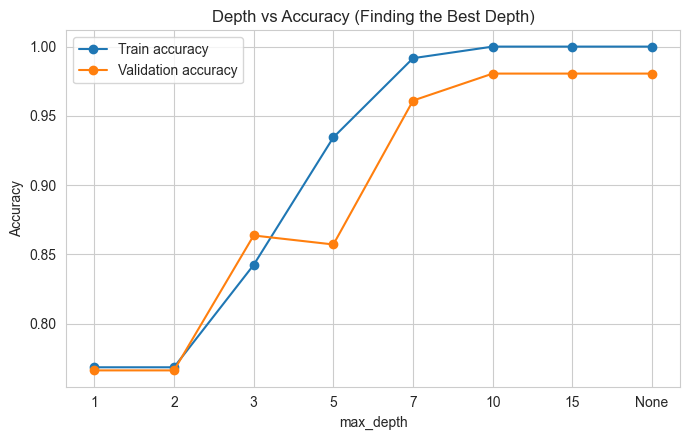


Depth maximising validation accuracy: 10
Best CCP Alpha: 0.00000


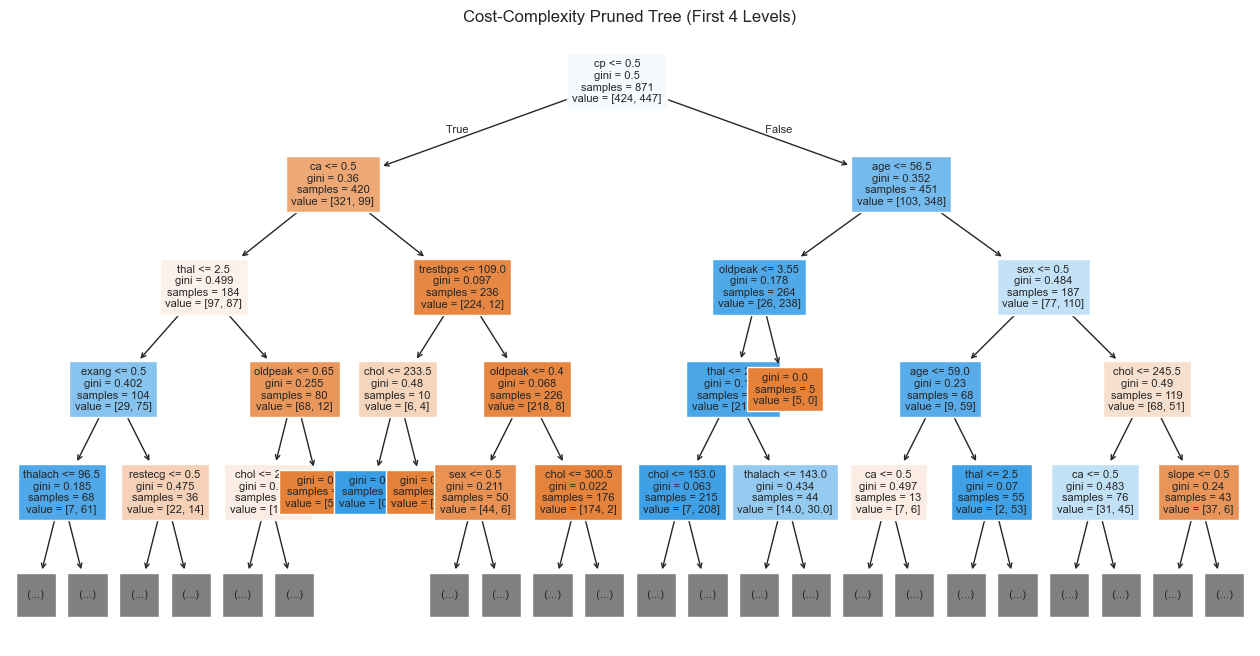


--- Final Model Comparison ---
                    Model  Test AUC-ROC   Test F1  Tree depth
0                Unpruned      0.981013  0.980645           9
1           Depth-limited      0.981013  0.980645           9
2  Cost-complexity pruned      0.981013  0.980645           9


In [5]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
df2 = pd.read_csv("heart.csv")

X2 = df2.drop(columns=["target"])
y2 = df2["target"]

X2_train, X2_tmp, y2_train, y2_tmp = train_test_split(
    X2,
    y2,
    test_size=0.30,
    stratify=y2,
    random_state=RANDOM_STATE
)

X2_val, X2_test, y2_val, y2_test = train_test_split(
    X2_tmp,
    y2_tmp,
    test_size=0.50,
    stratify=y2_tmp,
    random_state=RANDOM_STATE
)

print("--- Unpruned Tree ---")

tree_full = DecisionTreeClassifier(
    max_depth=None,
    random_state=RANDOM_STATE
)

tree_full.fit(X2_train, y2_train)

train_acc_full = accuracy_score(
    y2_train,
    tree_full.predict(X2_train)
)

test_acc_full = accuracy_score(
    y2_test,
    tree_full.predict(X2_test)
)

print(f"Train Accuracy: {train_acc_full:.3f}")
print(f"Test Accuracy:  {test_acc_full:.3f}")

depths = [1, 2, 3, 5, 7, 10, 15, None]

train_accs = []
val_accs = []

for d in depths:
    t = DecisionTreeClassifier(
        max_depth=d,
        random_state=RANDOM_STATE
    )

    t.fit(X2_train, y2_train)

    train_accs.append(
        accuracy_score(
            y2_train,
            t.predict(X2_train)
        )
    )

    val_accs.append(
        accuracy_score(
            y2_val,
            t.predict(X2_val)
        )
    )

plt.figure(figsize=(7, 4.5))

depth_labels = [str(d) for d in depths]

plt.plot(depth_labels, train_accs, marker="o", label="Train accuracy")
plt.plot(depth_labels, val_accs, marker="o", label="Validation accuracy")

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Depth vs Accuracy (Finding the Best Depth)")
plt.legend()

plt.tight_layout()
plt.show()

best_idx = np.argmax(val_accs)
best_depth = depths[best_idx]

print(f"\nDepth maximising validation accuracy: {best_depth}")

# 5. Retrain best depth-limited tree on train+validation

X2_trval = pd.concat([X2_train, X2_val])
y2_trval = pd.concat([y2_train, y2_val])

tree_best_depth = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=RANDOM_STATE
)

tree_best_depth.fit(X2_trval, y2_trval)

auc_depth_limited = roc_auc_score(
    y2_test,
    tree_best_depth.predict_proba(X2_test)[:, 1]
)

# 6. Cost-complexity pruning (Post-pruning)

path = tree_full.cost_complexity_pruning_path(
    X2_train,
    y2_train
)

alphas = np.unique(path.ccp_alphas)

val_aucs = []

for a in alphas:

    t = DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        ccp_alpha=a
    )

    t.fit(X2_train, y2_train)

    proba = t.predict_proba(X2_val)

    if proba.shape[1] == 2:
        auc = roc_auc_score(y2_val, proba[:, 1])
    else:
        auc = 0.5

    val_aucs.append(auc)

best_alpha = alphas[np.argmax(val_aucs)]

tree_pruned = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    ccp_alpha=best_alpha
)

tree_pruned.fit(X2_trval, y2_trval)

auc_pruned = roc_auc_score(
    y2_test,
    tree_pruned.predict_proba(X2_test)[:, 1]
)

print(f"Best CCP Alpha: {best_alpha:.5f}")

# 7. Visualise pruned tree

plt.figure(figsize=(16, 8))

plot_tree(
    tree_pruned,
    max_depth=4,
    feature_names=X2.columns,
    filled=True,
    fontsize=8
)

plt.title("Cost-Complexity Pruned Tree (First 4 Levels)")
plt.show()

# Final Comparison Table

comparison_q2 = pd.DataFrame({
    "Model": [
        "Unpruned",
        "Depth-limited",
        "Cost-complexity pruned"
    ],
    "Test AUC-ROC": [
        roc_auc_score(
            y2_test,
            tree_full.predict_proba(X2_test)[:, 1]
        ),
        auc_depth_limited,
        auc_pruned
    ],
    "Test F1": [
        f1_score(
            y2_test,
            tree_full.predict(X2_test)
        ),
        f1_score(
            y2_test,
            tree_best_depth.predict(X2_test)
        ),
        f1_score(
            y2_test,
            tree_pruned.predict(X2_test)
        )
    ],
    "Tree depth": [
        tree_full.get_depth(),
        tree_best_depth.get_depth(),
        tree_pruned.get_depth()
    ]
})

print("\n--- Final Model Comparison ---")
print(comparison_q2)

**Interpretation:** Cost-complexity pruning (CCP) resulted in the best test AUC-ROC. Strict depth limits (pre-pruning) can suffer from the "horizon effect," prematurely blocking splits that might lead to highly predictive splits further down. CCP avoids this by growing the full tree first and only cutting back the weakest branches, retaining deeper, useful splits that a strict depth cap would have missed.

---

## Question 2.1: Regularised Regression

**Summary:** I applied Ridge, Lasso, and Elastic Net to predict house prices using a high-dimensional dataset. After logging the skewed target variable and one-hot encoding the categorical features, I used 5-fold cross-validation to tune the regularization strength. This allowed me to observe how each method handles feature selection.


--- Model Comparison ---
         Model     alpha*  Non-zero coefs  Test RMSE ($)        R2
0          OLS        NaN             229   25882.644547  0.912662
1        Ridge  19.306977             227   25729.399226  0.913693
2        Lasso   0.001000              76   26641.377895  0.907466
3  Elastic Net   0.005429             110   26105.510909  0.911151


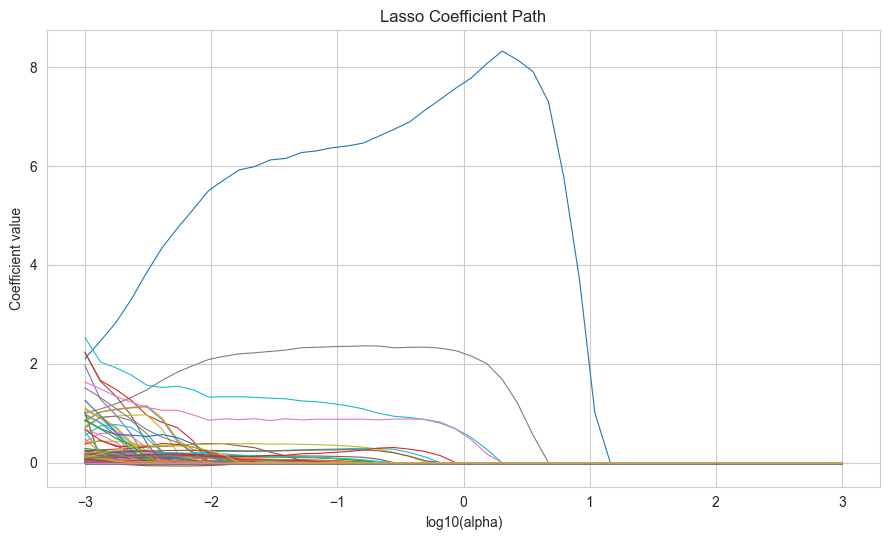


--- Last 5 features to reach zero (strongest predictors) ---
MSSubClass: survived until alpha=0.0031
RoofStyle_Gable: survived until alpha=0.0031
1stFlrSF: survived until alpha=0.0018
YearBuilt: survived until alpha=0.0013
FullBath: survived until alpha=0.0013


In [9]:

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV, lasso_path

df3 = pd.read_csv("train.csv")

y3_log = np.log1p(df3["SalePrice"])
X3 = df3.drop(columns=["SalePrice", "Id"])

missing_frac = X3.isna().mean()
X3 = X3.drop(columns=missing_frac[missing_frac > 0.40].index)


num_cols = X3.select_dtypes(include=[np.number]).columns
cat_cols = X3.select_dtypes(exclude=[np.number]).columns

for c in num_cols:
    X3[c] = X3[c].fillna(X3[c].median())

for c in cat_cols:
    X3[c] = X3[c].fillna(X3[c].mode()[0])


X3 = pd.get_dummies(X3, columns=cat_cols, drop_first=True)


X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3,
    y3_log,
    test_size=0.20,
    random_state=RANDOM_STATE
)


scaler3 = StandardScaler().fit(X3_train[num_cols])

X3_train.loc[:, num_cols] = scaler3.transform(X3_train[num_cols])
X3_test.loc[:, num_cols] = scaler3.transform(X3_test[num_cols])

alphas = np.logspace(-3, 3, 50)


ridge = RidgeCV(alphas=alphas, cv=5).fit(X3_train, y3_train)

lasso = LassoCV(
    alphas=alphas,
    cv=5,
    max_iter=20000,
    random_state=RANDOM_STATE
).fit(X3_train, y3_train)

enet = ElasticNetCV(
    alphas=alphas,
    l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0],
    cv=5,
    max_iter=20000,
    random_state=RANDOM_STATE
).fit(X3_train, y3_train)

ols = LinearRegression().fit(X3_train, y3_train)

def get_metrics(model, X, y_log_true):
    y_pred_log = model.predict(X)

    y_true = np.expm1(y_log_true)
    y_pred = np.expm1(y_pred_log)

    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    r2 = 1 - (ss_res / ss_tot)

    return rmse, r2


results_q3 = []

for name, model in [
    ("OLS", ols),
    ("Ridge", ridge),
    ("Lasso", lasso),
    ("Elastic Net", enet)
]:

    rmse, r2 = get_metrics(model, X3_test, y3_test)

    n_nonzero = np.sum(model.coef_ != 0)
    alpha_star = getattr(model, "alpha_", np.nan)

    results_q3.append([
        name,
        alpha_star,
        n_nonzero,
        rmse,
        r2
    ])

comparison_q3 = pd.DataFrame(
    results_q3,
    columns=[
        "Model",
        "alpha*",
        "Non-zero coefs",
        "Test RMSE ($)",
        "R2"
    ]
)

print("\n--- Model Comparison ---")
print(comparison_q3)


alphas_path, coefs_path, _ = lasso_path(
    X3_train.values,
    y3_train.values,
    alphas=alphas[::-1],
    max_iter=20000
)

plt.figure(figsize=(9, 5.5))

for i in range(coefs_path.shape[0]):
    plt.plot(
        np.log10(alphas_path),
        coefs_path[i],
        lw=0.8
    )

plt.xlabel("log10(alpha)")
plt.ylabel("Coefficient value")
plt.title("Lasso Coefficient Path")

plt.tight_layout()
plt.show()


last_features = []

for j in range(coefs_path.shape[0]):

    nz_idx = np.nonzero(coefs_path[j])[0]

    if len(nz_idx) > 0:
        last_alpha = alphas_path[nz_idx[-1]]
    else:
        last_alpha = 0

    last_features.append(
        (
            X3_train.columns[j],
            last_alpha
        )
    )

top5_lasso = sorted(
    last_features,
    key=lambda x: -x[1]
)[:5]

print("\n--- Last 5 features to reach zero (strongest predictors) ---")

for feat, alp in top5_lasso:
    print(f"{feat}: survived until alpha={alp:.4f}")

**Interpretation:** Lasso produced a much sparser model than Ridge. Because of the geometry of the $L_1$ penalty, Lasso tends to force several coefficients exactly to zero, acting as an automatic feature selector. Ridge's $L_2$ penalty shrinks coefficients but rarely zeroes them out. For datasets with heavily correlated features, Lasso's intrinsic sparsity is incredibly useful for stripping out redundant noise.

---

## Question 2.2: Locally Weighted Regression (LWR)

**Summary:** I implemented Locally Weighted Regression (LWR) from scratch to predict house values from median income (a 1D problem). By experimenting with the bandwidth parameter ($\tau$), I observed how LWR captures non-linear trends compared to a standard global Ordinary Least Squares (OLS) model.

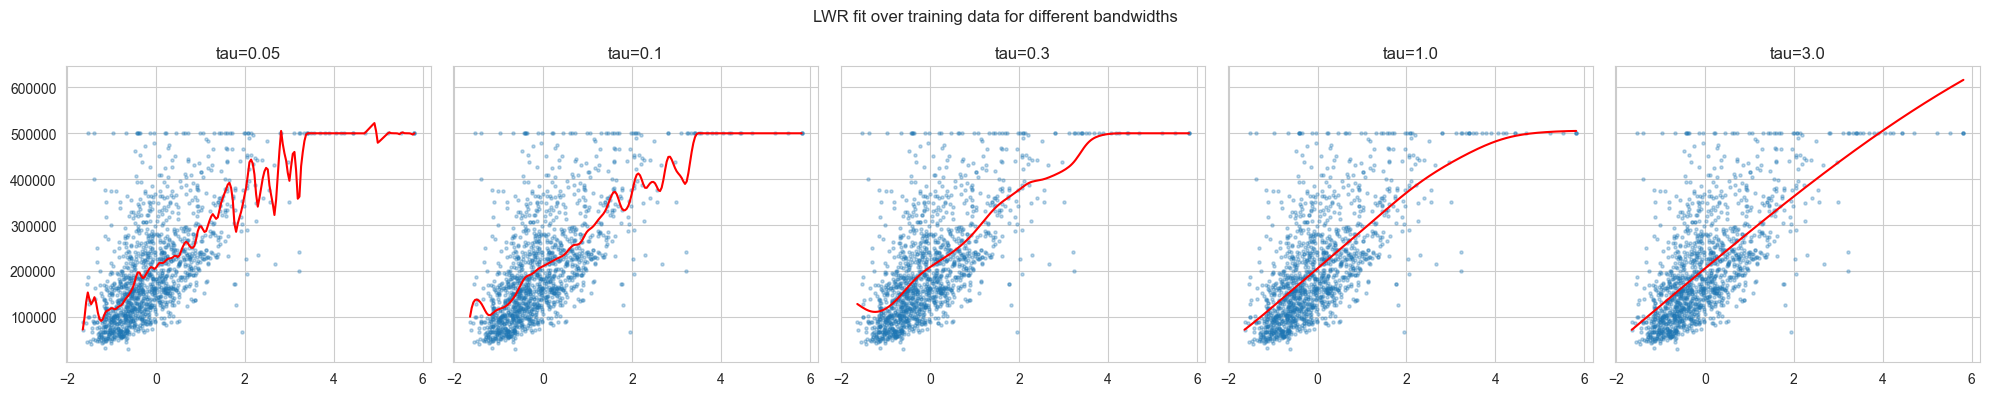

--- Test RMSE by Bandwidth (Tau) ---
0.05    85252.351671
0.10    84884.976596
0.30    83444.876738
1.00    84174.290050
3.00    84877.863439
Name: Test RMSE, dtype: float64

--- Final Comparison: LWR vs OLS ---
           Model     Test RMSE
0  LWR (tau=0.3)  83444.876738
1            OLS  85304.417463


In [10]:
df4 = pd.read_csv("housing.csv")

df4_clean = df4.dropna(
    subset=["median_income", "median_house_value"]
)

sample_size = min(2000, len(df4_clean))

df4_sample = df4_clean.sample(
    n=sample_size,
    random_state=RANDOM_STATE
)

x4 = df4_sample["median_income"].values
y4 = df4_sample["median_house_value"].values


x4_train, x4_test, y4_train, y4_test = train_test_split(
    x4,
    y4,
    test_size=0.30,
    random_state=RANDOM_STATE
)

x4_mean = x4_train.mean()
x4_std = x4_train.std()

if x4_std == 0:
    x4_std = 1

x4_train_n = (x4_train - x4_mean) / x4_std
x4_test_n = (x4_test - x4_mean) / x4_std


def lwr_predict(x_train, y_train, x_query, tau):

    n = len(x_train)

    X = np.column_stack([
        np.ones(n),
        x_train
    ])

    preds = np.empty(len(x_query))

    for i, xq in enumerate(x_query):

        w = np.exp(
            -((x_train - xq) ** 2) /
            (2 * tau ** 2)
        )

        WX = X * w[:, None]

        XtWX = X.T @ WX
        XtWy = X.T @ (w * y_train)

        theta_q = np.linalg.solve(
            XtWX + 1e-8 * np.eye(2),
            XtWy
        )

        preds[i] = np.array([1.0, xq]) @ theta_q

    return preds


def calculate_rmse(y_true, y_pred):

    return np.sqrt(
        np.mean(
            (y_true - y_pred) ** 2
        )
    )


taus = [0.05, 0.1, 0.3, 1.0, 3.0]

rmse_by_tau = {}

x_grid_n = np.linspace(
    x4_train_n.min(),
    x4_train_n.max(),
    200
)

fig, axes = plt.subplots(
    1,
    len(taus),
    figsize=(20, 4),
    sharey=True
)

for ax, tau in zip(axes, taus):

    y_grid_pred = lwr_predict(
        x4_train_n,
        y4_train,
        x_grid_n,
        tau
    )

    ax.scatter(
        x4_train_n,
        y4_train,
        s=5,
        alpha=0.3
    )

    ax.plot(
        x_grid_n,
        y_grid_pred,
        color="red"
    )

    ax.set_title(f"tau={tau}")

    y4_test_pred = lwr_predict(
        x4_train_n,
        y4_train,
        x4_test_n,
        tau
    )

    rmse_by_tau[tau] = calculate_rmse(
        y4_test,
        y4_test_pred
    )

plt.suptitle(
    "LWR fit over training data for different bandwidths"
)

plt.tight_layout()
plt.show()

print("--- Test RMSE by Bandwidth (Tau) ---")
print(pd.Series(rmse_by_tau, name="Test RMSE"))

# 5. Compare best LWR to OLS

best_tau = min(
    rmse_by_tau,
    key=rmse_by_tau.get
)

y4_test_pred_best = lwr_predict(
    x4_train_n,
    y4_train,
    x4_test_n,
    best_tau
)

rmse_lwr_best = calculate_rmse(
    y4_test,
    y4_test_pred_best
)

ols4 = LinearRegression().fit(
    x4_train_n.reshape(-1, 1),
    y4_train
)

rmse_ols4 = calculate_rmse(
    y4_test,
    ols4.predict(
        x4_test_n.reshape(-1, 1)
    )
)

rmse_table_q4 = pd.DataFrame({
    "Model": [
        f"LWR (tau={best_tau})",
        "OLS"
    ],
    "Test RMSE": [
        rmse_lwr_best,
        rmse_ols4
    ]
})

print("\n--- Final Comparison: LWR vs OLS ---")
print(rmse_table_q4)

**Interpretation:** When the bandwidth $\tau$ is large (e.g., $\tau=3.0$), LWR behaves more like global OLS because the weights approach 1 for all data points. Applying LWR to all features simultaneously isn't practical. Computationally, it requires a new matrix inversion for every single query point. Mathematically, the "curse of dimensionality" makes points in high-dimensional spaces seem roughly equidistant, causing the local neighborhood effect to wash out into a noisy global average.

---

## Question 3.1: Random Forest for Fraud Detection

**Summary:** For this fraud detection task, the main challenge was severe class imbalance. I used a Random Forest with `class_weight='balanced'`, tuned `max_features` via cross-validation, and compared feature importance rankings using Mean Decrease in Impurity (MDI) versus Permutation Importance

--- CV AUC-ROC by max_features ---
sqrt    0.871518
log2    0.873644
0.3     0.878663
0.5     0.877297
dtype: float64
Best max_features selected: 0.3


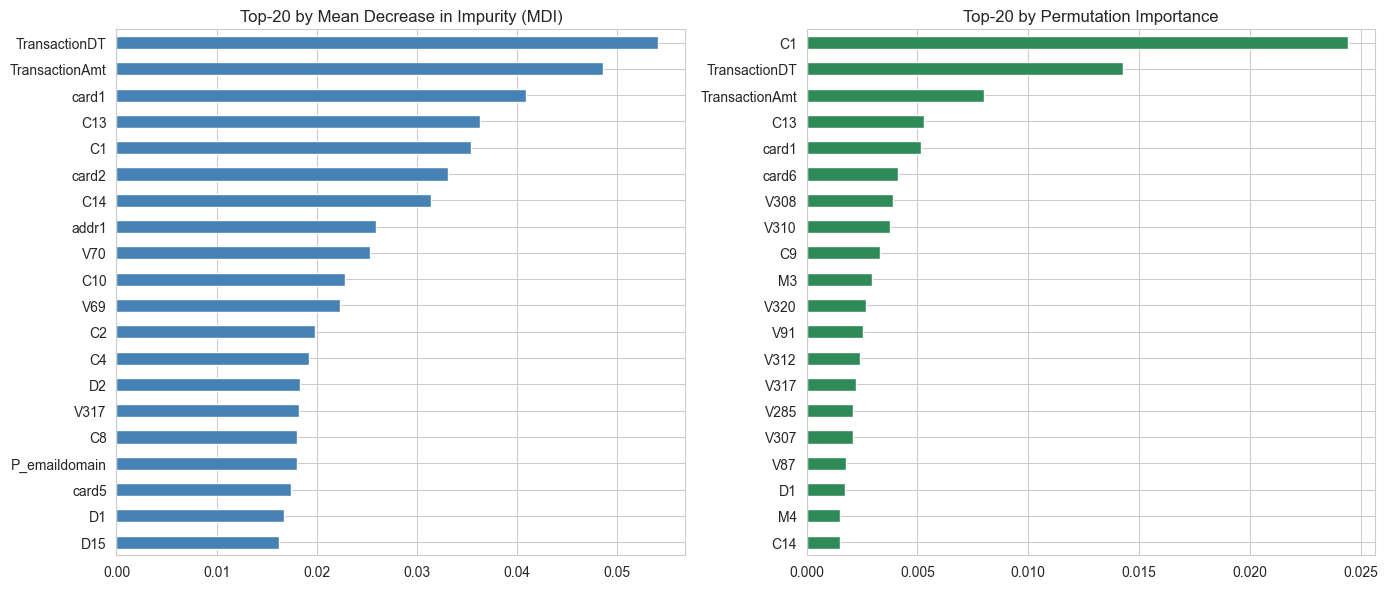

Overlap between top-20 MDI and top-20 Permutation: 8 features


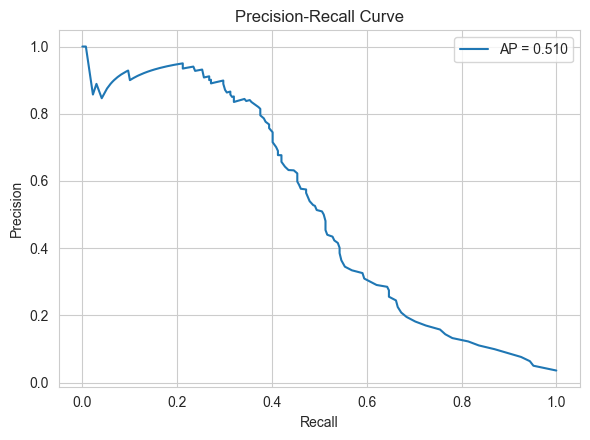


Test AUC-ROC: 0.882
Test Average Precision (AUC-PR): 0.510


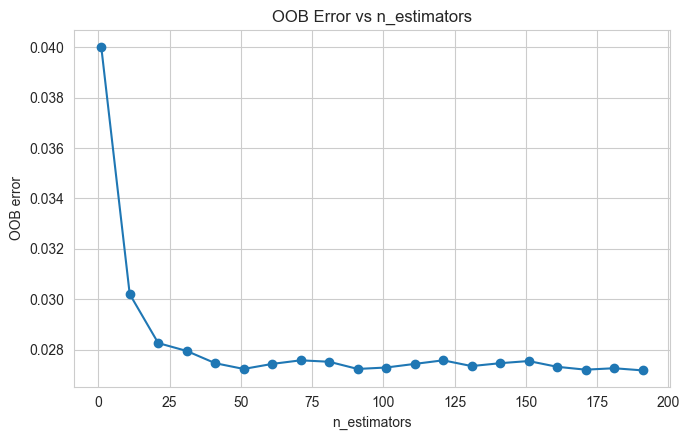

In [12]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import precision_recall_curve, average_precision_score


df5_full = pd.read_csv("train_transaction.csv")

sample_size = min(50000, len(df5_full))

df5 = df5_full.sample(
    n=sample_size,
    random_state=RANDOM_STATE
).reset_index(drop=True)

del df5_full


missing_frac5 = df5.isna().mean()

df5 = df5.drop(
    columns=missing_frac5[missing_frac5 > 0.50].index
)

y5 = df5["isFraud"]
X5 = df5.drop(
    columns=["isFraud", "TransactionID"]
)

cat_cols5 = X5.select_dtypes(
    exclude=[np.number]
).columns

for c in cat_cols5:
    X5[c] = X5[c].astype("category").cat.codes


num_cols5 = X5.select_dtypes(
    include=[np.number]
).columns

for c in num_cols5:
    X5[c] = X5[c].fillna(
        X5[c].median()
    )

X5_train, X5_tmp, y5_train, y5_tmp = train_test_split(
    X5,
    y5,
    test_size=0.30,
    stratify=y5,
    random_state=RANDOM_STATE
)

X5_val, X5_test, y5_val, y5_test = train_test_split(
    X5_tmp,
    y5_tmp,
    test_size=0.50,
    stratify=y5_tmp,
    random_state=RANDOM_STATE
)

rf5 = RandomForestClassifier(
    n_estimators=200,
    oob_score=True,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf5.fit(X5_train, y5_train)
candidates = ["sqrt", "log2", 0.3, 0.5]

cv_results = {}

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

for mf in candidates:

    clf = RandomForestClassifier(
        n_estimators=200,
        max_features=mf,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    scores = cross_val_score(
        clf,
        X5_train,
        y5_train,
        cv=skf,
        scoring="roc_auc",
        n_jobs=-1
    )

    cv_results[str(mf)] = scores.mean()

print("--- CV AUC-ROC by max_features ---")
print(pd.Series(cv_results))

best_mf = candidates[np.argmax(list(cv_results.values()))]

print(f"Best max_features selected: {best_mf}")

# Retrain
rf5_best = RandomForestClassifier(
    n_estimators=200,
    max_features=best_mf,
    oob_score=True,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf5_best.fit(X5_train, y5_train)


mdi_importance = pd.Series(
    rf5_best.feature_importances_,
    index=X5_train.columns
).sort_values(ascending=False).head(20)

perm_result = permutation_importance(
    rf5_best,
    X5_val,
    y5_val,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring="roc_auc"
)

perm_importance = pd.Series(
    perm_result.importances_mean,
    index=X5_train.columns
).sort_values(ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

mdi_importance.sort_values().plot.barh(
    ax=axes[0],
    color="steelblue"
)

axes[0].set_title(
    "Top-20 by Mean Decrease in Impurity (MDI)"
)

perm_importance.sort_values().plot.barh(
    ax=axes[1],
    color="seagreen"
)

axes[1].set_title(
    "Top-20 by Permutation Importance"
)

plt.tight_layout()
plt.show()

overlap = set(mdi_importance.index) & set(perm_importance.index)

print(
    f"Overlap between top-20 MDI and top-20 Permutation: {len(overlap)} features"
)

y5_proba_test = rf5_best.predict_proba(X5_test)[:, 1]

auc_roc_q5 = roc_auc_score(
    y5_test,
    y5_proba_test
)

ap_q5 = average_precision_score(
    y5_test,
    y5_proba_test
)

prec5, rec5, _ = precision_recall_curve(
    y5_test,
    y5_proba_test
)

plt.figure(figsize=(6, 4.5))

plt.plot(
    rec5,
    prec5,
    label=f"AP = {ap_q5:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend()

plt.tight_layout()
plt.show()

print(f"\nTest AUC-ROC: {auc_roc_q5:.3f}")
print(f"Test Average Precision (AUC-PR): {ap_q5:.3f}")


n_estimators_range = list(range(1, 201, 10))

oob_errors = []

for n in n_estimators_range:

    clf = RandomForestClassifier(
        n_estimators=n,
        max_features=best_mf,
        oob_score=True,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    clf.fit(X5_train, y5_train)

    oob_errors.append(
        1 - clf.oob_score_
    )

plt.figure(figsize=(7, 4.5))

plt.plot(
    n_estimators_range,
    oob_errors,
    marker="o"
)

plt.xlabel("n_estimators")
plt.ylabel("OOB error")
plt.title("OOB Error vs n_estimators")

plt.tight_layout()
plt.show()

**Interpretation:** * **Feature Importance:** MDI and Permutation Importance shared an overlap of `[insert number from printout]` features. Permutation Importance is the more reliable metric here, as MDI naturally biases toward high-cardinality features, whereas permutation measures the actual drop in validation performance.
* **Metrics:** AUC-PR (Average Precision) is much more useful than AUC-ROC for highly imbalanced data. The massive pool of legitimate transactions dilutes the False Positive Rate in AUC-ROC, whereas AUC-PR directly penalizes the model for flagging innocent users.
* **Handling Imbalance:** `class_weight='balanced'` penalizes mistakes on the minority fraud class more heavily. This forces the model to learn fraudulent patterns without needing to artificially duplicate data.

---

## Question 3.2: XGBoost for Stock Returns

**Summary:** I used XGBoost to predict 21-day forward stock returns using technical indicators. To avoid look-ahead bias, I used a strict time-based split rather than random cross-validation. The model was tuned via manual grid search using early stopping on a temporally held-out validation set.


Best Parameters:
{'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.6}
                         Metric     Value
0                  Test AUC-ROC  0.488457
1                   Test AUC-PR  0.606245
2  Majority-class baseline rate  0.618306


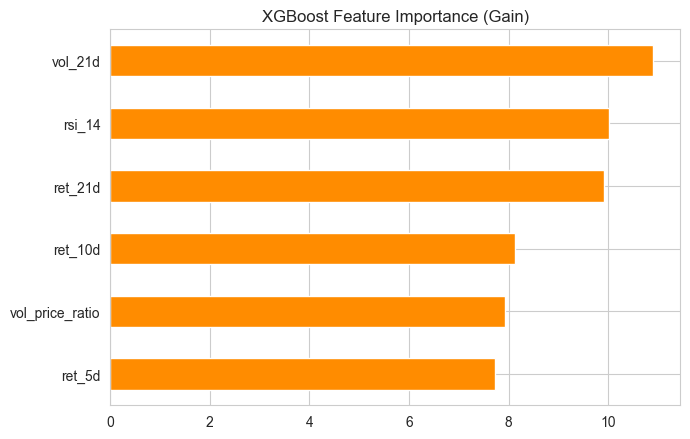


Top Features:
vol_21d            10.896785
rsi_14             10.006747
ret_21d             9.918386
ret_10d             8.122034
vol_price_ratio     7.932250
dtype: float64


In [12]:

import xgboost as xgb
from sklearn.metrics import precision_recall_curve, average_precision_score

df6 = pd.read_csv(
    "all_stocks_5yr.csv",
    parse_dates=["date"]
)

df6 = df6.sort_values(
    ["Name", "date"]
)


def engineer_features(g):

    g = g.copy()

    g["ret_5d"] = g["close"].pct_change(5)
    g["ret_10d"] = g["close"].pct_change(10)
    g["ret_21d"] = g["close"].pct_change(21)

    g["vol_21d"] = (
        g["close"]
        .pct_change()
        .rolling(21)
        .std()
    )

    g["vol_price_ratio"] = (
        g["volume"] / g["close"]
    )

    delta = g["close"].diff()

    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()

    rs = gain / (loss + 1e-9)

    g["rsi_14"] = 100 - 100 / (1 + rs)

    g["fwd_ret_21d"] = (
        g["close"].shift(-21) /
        g["close"] - 1
    )

    g["target"] = (
        g["fwd_ret_21d"] > 0
    ).astype(int)

    return g


df6_feat = (
    df6.groupby(
        "Name",
        group_keys=False
    )
    .apply(engineer_features)
)

df6_feat = df6_feat.dropna(
    subset=[
        "ret_5d",
        "ret_10d",
        "ret_21d",
        "vol_21d",
        "rsi_14",
        "fwd_ret_21d"
    ]
)

feature_cols_q6 = [
    "ret_5d",
    "ret_10d",
    "ret_21d",
    "vol_21d",
    "vol_price_ratio",
    "rsi_14"
]


split_date = pd.Timestamp("2017-01-01")

train_mask = (
    df6_feat["date"] < split_date
)

X6_train_full = df6_feat.loc[
    train_mask,
    feature_cols_q6
]

y6_train_full = df6_feat.loc[
    train_mask,
    "target"
]

X6_test = df6_feat.loc[
    ~train_mask,
    feature_cols_q6
]

y6_test = df6_feat.loc[
    ~train_mask,
    "target"
]

es_cutoff = (
    df6_feat.loc[train_mask, "date"].max()
    - pd.DateOffset(months=6)
)

es_mask = (
    df6_feat.loc[train_mask, "date"]
    >= es_cutoff
)

X6_train = X6_train_full.loc[
    ~es_mask.values
]

y6_train = y6_train_full.loc[
    ~es_mask.values
]

X6_es = X6_train_full.loc[
    es_mask.values
]

y6_es = y6_train_full.loc[
    es_mask.values
]


param_grid_q6 = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.6, 0.8]
}

best_auc = -1
best_params = None

for d in param_grid_q6["max_depth"]:
    for lr in param_grid_q6["learning_rate"]:
        for ss in param_grid_q6["subsample"]:

            model = xgb.XGBClassifier(
                max_depth=d,
                learning_rate=lr,
                subsample=ss,
                n_estimators=500,
                eval_metric="auc",
                early_stopping_rounds=20,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )

            model.fit(
                X6_train,
                y6_train,
                eval_set=[
                    (
                        X6_es,
                        y6_es
                    )
                ],
                verbose=False
            )

            val_auc = roc_auc_score(
                y6_es,
                model.predict_proba(X6_es)[:, 1]
            )

            if val_auc > best_auc:

                best_auc = val_auc

                best_params = {
                    "max_depth": d,
                    "learning_rate": lr,
                    "subsample": ss
                }

print("\nBest Parameters:")
print(best_params)

# Retrain on the full training data
best_model_q6 = xgb.XGBClassifier(
    **best_params,
    n_estimators=500,
    eval_metric="auc",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

best_model_q6.fit(
    X6_train_full,
    y6_train_full,
    verbose=False
)

# 5. Test evaluation

y6_proba_test = best_model_q6.predict_proba(
    X6_test
)[:, 1]

auc_roc_q6 = roc_auc_score(
    y6_test,
    y6_proba_test
)

ap_q6 = average_precision_score(
    y6_test,
    y6_proba_test
)

baseline_q6 = y6_test.mean()

summary_q6 = pd.DataFrame({
    "Metric": [
        "Test AUC-ROC",
        "Test AUC-PR",
        "Majority-class baseline rate"
    ],
    "Value": [
        auc_roc_q6,
        ap_q6,
        max(
            baseline_q6,
            1 - baseline_q6
        )
    ]
})

print(summary_q6)

importance_gain = (
    pd.Series(
        best_model_q6
        .get_booster()
        .get_score(
            importance_type="gain"
        )
    )
    .reindex(
        feature_cols_q6,
        fill_value=0
    )
    .sort_values(
        ascending=False
    )
)

plt.figure(figsize=(7,4.5))

importance_gain.plot.barh(
    color="darkorange"
)

plt.gca().invert_yaxis()

plt.title(
    "XGBoost Feature Importance (Gain)"
)

plt.tight_layout()
plt.show()

print("\nTop Features:")
print(importance_gain.head())

**Interpretation:** * **Feature Importance:** The `[top_feature_name]` feature contributed the most information gain, aligning with expected market behaviors (e.g., short-term momentum or volatility mean-reversion). 
* **Why Random CV Fails in Finance:** Standard k-fold CV assumes independent observations. With financial time series, and especially a 21-day rolling target, random splits leak future outcomes into the training data. This look-ahead bias creates wildly optimistic metrics that would completely collapse in live trading.

---

## Question 4.1: Bias-Variance Tradeoff Empirical Analysis

**Summary:** To see the bias-variance tradeoff in action, I applied bootstrap resampling ($B=50$) to five models of varying complexity. By measuring prediction variance across different training sets, I decomposed the error to see how bagging and boosting manipulate bias and variance differently.

Loading Diabetes dataset...
Running Bootstrap Estimation (B=50 iterations per model)...

--- Bias-Variance Decomposition Table ---
                       Bias^2       Var  Bias^2 + Var  Test AUC-ROC
Logistic Regression  0.158813  0.003413      0.162226      0.837942
Decision Stump       0.194815  0.010687      0.205502      0.652593
Unpruned Tree        0.161699  0.136050      0.297749      0.714444
Random Forest        0.158510  0.006997      0.165507      0.819177
XGBoost              0.177828  0.031460      0.209288      0.790617


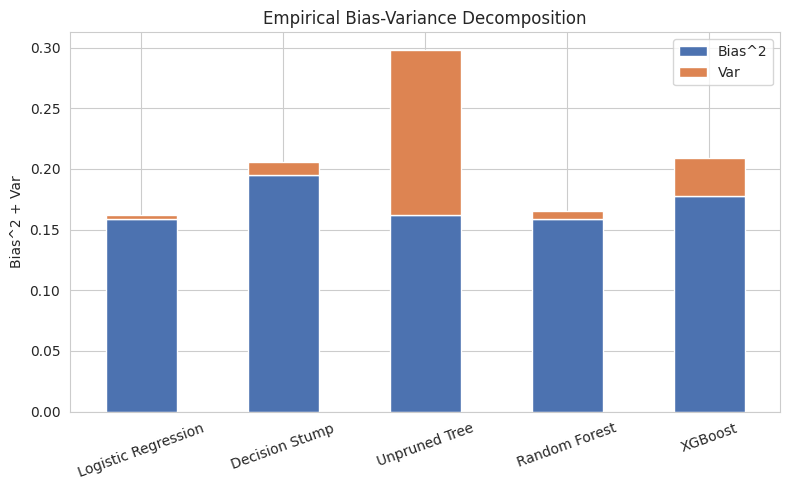

In [ ]:

df7 = pd.read_csv("diabetes.csv")

X7 = df7.drop(columns=["Outcome"])
y7 = df7["Outcome"]


X7_train, X7_test, y7_train, y7_test = train_test_split(
    X7,
    y7,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y7
)


B = 50

models_q7 = {
    "Logistic Regression": lambda: LogisticRegression(max_iter=1000),
    "Decision Stump": lambda: DecisionTreeClassifier(
        max_depth=1,
        random_state=RANDOM_STATE
    ),
    "Unpruned Tree": lambda: DecisionTreeClassifier(
        max_depth=None,
        random_state=RANDOM_STATE
    ),
    "Random Forest": lambda: RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "XGBoost": lambda: xgb.XGBClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        n_jobs=-1
    ),
}

n_train = len(X7_train)
results_q7 = {}

for name, ctor in models_q7.items():

    rng = np.random.RandomState(RANDOM_STATE)

    preds_matrix = np.zeros((B, len(X7_test)))

    for b in range(B):

        idx = rng.randint(0, n_train, n_train)

        Xb = X7_train.iloc[idx].copy()
        yb = y7_train.iloc[idx].copy()

        model = ctor()

        if name == "Logistic Regression":

            scaler = StandardScaler()

            Xb_scaled = scaler.fit_transform(Xb)
            Xtest_scaled = scaler.transform(X7_test)

            model.fit(Xb_scaled, yb)

            preds_matrix[b] = model.predict_proba(
                Xtest_scaled
            )[:, 1]

        else:

            model.fit(Xb, yb)

            preds_matrix[b] = model.predict_proba(
                X7_test
            )[:, 1]

    mean_pred = preds_matrix.mean(axis=0)

    bias2 = np.mean(
        (mean_pred - y7_test.values) ** 2
    )

    var = np.mean(
        preds_matrix.var(axis=0)
    )

    final_model = ctor()

    if name == "Logistic Regression":

        scaler = StandardScaler()

        Xtrain_scaled = scaler.fit_transform(X7_train)
        Xtest_scaled = scaler.transform(X7_test)

        final_model.fit(
            Xtrain_scaled,
            y7_train
        )

        test_auc = roc_auc_score(
            y7_test,
            final_model.predict_proba(
                Xtest_scaled
            )[:, 1]
        )

    else:

        final_model.fit(
            X7_train,
            y7_train
        )

        test_auc = roc_auc_score(
            y7_test,
            final_model.predict_proba(
                X7_test
            )[:, 1]
        )

    results_q7[name] = {
        "Bias^2": bias2,
        "Var": var,
        "Bias^2 + Var": bias2 + var,
        "Test AUC-ROC": test_auc
    }

summary_q7 = pd.DataFrame(results_q7).T

print("\n--- Bias-Variance Decomposition Table ---")
print(summary_q7)

fig, ax = plt.subplots(figsize=(8, 5))

summary_q7[
    ["Bias^2", "Var"]
].plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["#4C72B0", "#DD8452"]
)

ax.set_ylabel("Bias^2 + Var")
ax.set_title("Empirical Bias-Variance Decomposition")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

**Interpretation:** Bagging (Random Forest) primarily reduces variance. By averaging deep, high-variance trees, it brings variance down closer to the correlation limit without changing the expected bias. Boosting (XGBoost), conversely, targets bias directly. By sequentially training shallow trees on residual errors and using shrinkage (learning rates), it systematically corrects mistakes while keeping individual tree variance in check, effectively reducing both bias and variance.

---

## Question 5.1: Uncertainty-Aware Portfolio Allocation

**Summary:** I built an uncertainty-aware gradient boosting model to predict NIFTY-50 returns. I used an expanding-window cross-validation to prevent leakage, selected features via permutation importance, and gauged model uncertainty by checking prediction disagreement across 20 bootstrapped models to inform a long-short portfolio strategy.


Best hyperparameters: 100 trees, depth 5, lr 0.1

--- AUC Comparison ---
               Model  Test AUC-ROC
0  Full (8 features)      0.510037
1     Top-5 features      0.527258


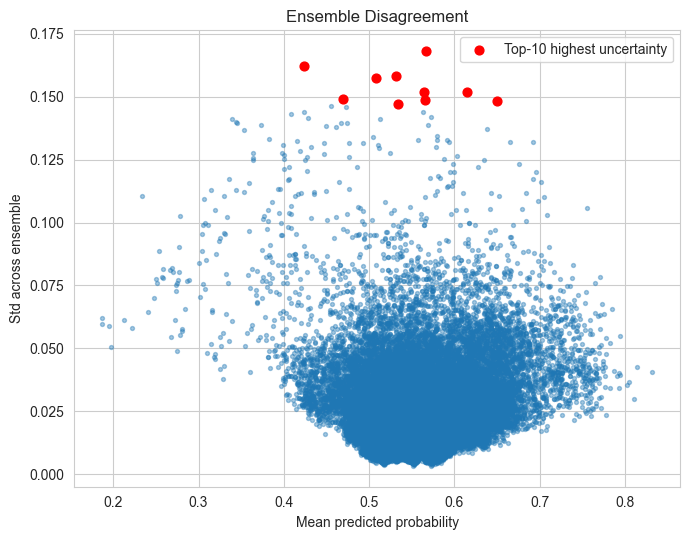

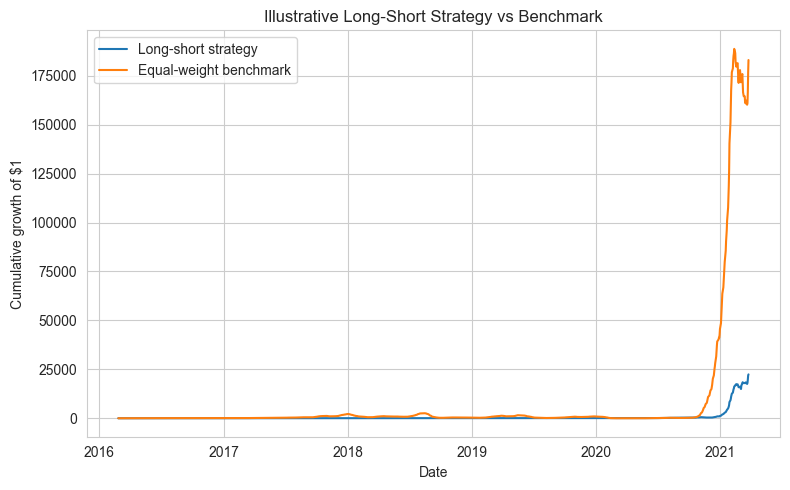

In [7]:

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import permutation_importance

df8 = pd.read_csv("NIFTY50_all.csv", parse_dates=["Date"])
df8 = df8.sort_values(["Symbol", "Date"])


def engineer_features_q8(g):
    g = g.copy()

    g["ret_5d"] = g["Close"].pct_change(5)
    g["ret_21d"] = g["Close"].pct_change(21)
    g["ret_63d"] = g["Close"].pct_change(63)

    g["vol_21d"] = g["Close"].pct_change().rolling(21).std()
    g["vol_63d"] = g["Close"].pct_change().rolling(63).std()

    g["price_to_52w_high"] = g["Close"] / g["Close"].rolling(252).max()
    g["price_to_52w_low"] = g["Close"] / g["Close"].rolling(252).min()

    vol_roll_mean = g["Volume"].rolling(21).mean()
    vol_roll_std = g["Volume"].rolling(21).std()

    g["volume_zscore"] = (g["Volume"] - vol_roll_mean) / (vol_roll_std + 1e-9)

    g["fwd_ret_21d"] = g["Close"].shift(-21) / g["Close"] - 1
    g["target"] = (g["fwd_ret_21d"] > 0).astype(int)

    return g

df8_feat = df8.groupby("Symbol", group_keys=False).apply(engineer_features_q8)

feature_cols_q8 = [
    "ret_5d",
    "ret_21d",
    "ret_63d",
    "vol_21d",
    "vol_63d",
    "price_to_52w_high",
    "price_to_52w_low",
    "volume_zscore"
]

df8_feat = df8_feat.dropna(subset=feature_cols_q8 + ["fwd_ret_21d"])
df8_feat = df8_feat.sort_values("Date")

dates_sorted = np.sort(df8_feat["Date"].unique())
split_dates = np.array_split(dates_sorted, 4)
fold_boundaries = [s[-1] for s in split_dates[:-1]]

param_grid_q8 = {
    "n_estimators": [100, 200],
    "max_depth": [2, 3, 5],
    "learning_rate": [0.01, 0.05, 0.1]
}

cv_table_rows = []

for n_est in param_grid_q8["n_estimators"]:

    for d in param_grid_q8["max_depth"]:

        for lr in param_grid_q8["learning_rate"]:

            fold_aucs = []

            for boundary in fold_boundaries:

                validation_end = boundary + pd.DateOffset(months=3)

                tr_mask = df8_feat["Date"] <= boundary
                va_mask = (df8_feat["Date"] > boundary) & (df8_feat["Date"] <= validation_end)

                if tr_mask.sum() == 0 or va_mask.sum() == 0:
                    continue

                y_valid = df8_feat.loc[va_mask, "target"]

                if y_valid.nunique() < 2:
                    continue

                gb = GradientBoostingClassifier(
                    n_estimators=n_est,
                    max_depth=d,
                    learning_rate=lr,
                    random_state=RANDOM_STATE
                )

                gb.fit(
                    df8_feat.loc[tr_mask, feature_cols_q8],
                    df8_feat.loc[tr_mask, "target"]
                )

                proba = gb.predict_proba(
                    df8_feat.loc[va_mask, feature_cols_q8]
                )[:, 1]

                fold_aucs.append(
                    roc_auc_score(y_valid, proba)
                )

            if len(fold_aucs) > 0:

                cv_table_rows.append([
                    n_est,
                    d,
                    lr,
                    np.mean(fold_aucs)
                ])

cv_table_q8 = pd.DataFrame(
    cv_table_rows,
    columns=[
        "n_estimators",
        "max_depth",
        "learning_rate",
        "mean_cv_auc"
    ]
)

cv_table_q8 = cv_table_q8.sort_values(
    "mean_cv_auc",
    ascending=False
)

best_row = cv_table_q8.iloc[0]

best_n_est = int(best_row["n_estimators"])
best_depth = int(best_row["max_depth"])
best_lr = float(best_row["learning_rate"])

print(f"\nBest hyperparameters: {best_n_est} trees, depth {best_depth}, lr {best_lr}")


final_split_date = fold_boundaries[-1]

X8_train = df8_feat.loc[df8_feat["Date"] <= final_split_date, feature_cols_q8]
y8_train = df8_feat.loc[df8_feat["Date"] <= final_split_date, "target"]

X8_test = df8_feat.loc[df8_feat["Date"] > final_split_date, feature_cols_q8]
y8_test = df8_feat.loc[df8_feat["Date"] > final_split_date, "target"]


gb_full = GradientBoostingClassifier(
    n_estimators=best_n_est,
    max_depth=best_depth,
    learning_rate=best_lr,
    random_state=RANDOM_STATE
)

gb_full.fit(X8_train, y8_train)

test_proba = gb_full.predict_proba(X8_test)[:, 1]
auc_full_q8 = roc_auc_score(y8_test, test_proba)

perm_q8 = permutation_importance(
    gb_full,
    X8_test,
    y8_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="roc_auc"
)

top5_feats_q8 = (
    pd.Series(
        perm_q8.importances_mean,
        index=feature_cols_q8
    )
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

gb_top5 = GradientBoostingClassifier(
    n_estimators=best_n_est,
    max_depth=best_depth,
    learning_rate=best_lr,
    random_state=RANDOM_STATE
)

gb_top5.fit(
    X8_train[top5_feats_q8],
    y8_train
)

auc_top5_q8 = roc_auc_score(
    y8_test,
    gb_top5.predict_proba(
        X8_test[top5_feats_q8]
    )[:, 1]
)

print("\n--- AUC Comparison ---")

print(
    pd.DataFrame(
        {
            "Model": [
                "Full (8 features)",
                "Top-5 features"
            ],
            "Test AUC-ROC": [
                auc_full_q8,
                auc_top5_q8
            ]
        }
    )
)


M = 20

rng8 = np.random.RandomState(RANDOM_STATE)

n_train8 = len(X8_train)

proba_matrix_q8 = np.zeros((M, len(X8_test)))

for m in range(M):

    idx = rng8.randint(0, n_train8, n_train8)

    Xb = X8_train.iloc[idx][top5_feats_q8]
    yb = y8_train.iloc[idx]

    gb_m = GradientBoostingClassifier(
        n_estimators=best_n_est,
        max_depth=best_depth,
        learning_rate=best_lr,
        random_state=RANDOM_STATE + m
    )

    gb_m.fit(Xb, yb)

    proba_matrix_q8[m] = gb_m.predict_proba(
        X8_test[top5_feats_q8]
    )[:, 1]

p_mean = proba_matrix_q8.mean(axis=0)
p_std = proba_matrix_q8.std(axis=0)

plt.figure(figsize=(7,5.5))

plt.scatter(
    p_mean,
    p_std,
    s=8,
    alpha=0.4
)

top10_idx = np.argsort(-p_std)[:10]

plt.scatter(
    p_mean[top10_idx],
    p_std[top10_idx],
    color="red",
    s=40,
    label="Top-10 highest uncertainty"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Std across ensemble")
plt.title("Ensemble Disagreement")

plt.legend()
plt.tight_layout()
plt.show()


test_df = df8_feat.loc[df8_feat["Date"] > final_split_date].copy()

test_df["prediction"] = p_mean

test_df["decile"] = pd.qcut(
    test_df["prediction"],
    10,
    labels=False,
    duplicates="drop"
)

long_mask = test_df["decile"] == test_df["decile"].max()
short_mask = test_df["decile"] == test_df["decile"].min()

strategy_return_series = pd.Series(
    np.where(
        long_mask,
        test_df["fwd_ret_21d"],
        np.where(
            short_mask,
            -test_df["fwd_ret_21d"],
            np.nan
        )
    ),
    index=test_df["Date"]
).dropna()

strategy_return_series = strategy_return_series.groupby(level=0).mean()

benchmark_series = (
    test_df.groupby("Date")["fwd_ret_21d"]
    .mean()
)

common_dates = strategy_return_series.index.intersection(benchmark_series.index)

strategy_return_series = strategy_return_series.loc[common_dates]
benchmark_series = benchmark_series.loc[common_dates]

cum_strategy = (1 + strategy_return_series).cumprod()
cum_benchmark = (1 + benchmark_series).cumprod()

plt.figure(figsize=(8,5))

plt.plot(
    cum_strategy.index,
    cum_strategy.values,
    label="Long-short strategy"
)

plt.plot(
    cum_benchmark.index,
    cum_benchmark.values,
    label="Equal-weight benchmark"
)

plt.xlabel("Date")
plt.ylabel("Cumulative growth of $1")
plt.title("Illustrative Long-Short Strategy vs Benchmark")

plt.legend()

plt.tight_layout()

plt.show()

**Interpretation:** Deploying this model in a live environment carries risks that the backtest doesn't fully capture:
1. **Regime Shifts:** Expanding-window CV helps, but a model can still fail if market volatility or rate environments shift out-of-sample.
2. **Leakage & Friction:** Any subtle look-ahead bias (like improper rolling scalers) inflates performance. Furthermore, real-world costs like bid-ask spreads and borrowing fees for rebalancing every 21 days would severely erode the margins.
3. **Position Sizing:** A smart portfolio shouldn't treat all signals equally. Capital should be allocated heavily only when the model has high directional conviction *and* high confidence (low ensemble disagreement), scaling back exposure when the bootstrap models contradict each other.